In [1]:
import torch
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import torch.utils.data as Data
from torch.optim.lr_scheduler import CosineAnnealingLR,LinearLR, SequentialLR
import datetime
import Network_FDD_CBAM as FDD
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['KMP_DUPLICATE_LIB_OK']='True'

D:\Compiler\anaconda3\envs\ofdm_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')
if not os.path.exists('results'):
    os.makedirs('results')
DATA_DIR = "data"

In [3]:
import subprocess
def temperatureCheck():
    try:
        # CPU
        cpu_temp = 95#psutil.sensors_temperatures().get('coretemp', [])[0].current if 'coretemp' in psutil.sensors_temperatures() else None
        # GPU
        gpu_query = subprocess.run(['nvidia-smi', '--query-gpu=temperature.gpu', '--format=csv,noheader,nounits'], capture_output=True, text=True)
        gpu_temp = int(gpu_query.stdout.strip())

        print(f"[TempCheck] GPU:{gpu_temp}°C")

        # 安全阈值
        # if cpu_temp and cpu_temp > 90:
        #     print("[TempCheck] CPU 过热，暂停 60 秒冷却")
        #     time.sleep(60)
        if gpu_temp and gpu_temp > 80:
            print("[TempCheck] GPU 过热，暂停 60 秒冷却")
            time.sleep(60)

    except Exception as e:
        print(f"[TempCheck] 获取温度信息失败: {e}")

In [4]:
def set_seed(seed):
    """
    函数功能：为所有相关的库设置随机种子，以确保实验的可复现性
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [5]:
def checkConvergence(epoch,
                     test_losses,
                     start_epoch=12,
                     window_size=5,
                     growth_threshold=0.1,
                     pass_score=12):
    """
    检查训练是否提前收敛或陷入停滞的函数。

    Args:
        epoch (int): 当前的训练轮次 (从0开始)。
        test_losses (list): 包含至今所有测试集性能（SE）的历史记录列表。
        start_epoch (int): 从第几轮开始进行检查。
        window_size (int): 需要连续多少轮的增长率都低于阈值才判断为收敛。
        growth_threshold (float): 增长率的阈值，低于此值被认为是“增长较小”。

    Returns:
        bool: 如果判断为收敛，则返回 True，否则返回 False。
    """

    if epoch < start_epoch:
        return False
    if test_losses[-1] > pass_score:
        return False
    recent_performance = test_losses[-(window_size + 1):]
    for i in range(window_size):
        growth = recent_performance[-(i+1)] - recent_performance[-(i+2)]
        if growth >= growth_threshold:
            return False

    print(f"\n[Convergence Watcher] 在第 {epoch} 轮检测到性能停滞!")
    print(f"    - 已连续 {window_size} 轮的性能增长率低于阈值 ({growth_threshold})")
    print("    - 提前终止本次训练。")
    return True

In [6]:
def train(Nc, N, Nt, B, Nr, L, SNR_dB, K, EPOCH, BATCH_SIZE):
    shoulian = np.zeros(EPOCH)
    snr = 10**(SNR_dB/10) / K
    parm_set = [Nc, Nt, Nr, snr, B, K]

    # H_train = torch.load(os.path.join(DATA_DIR, f'H_train_N{N}.pt'))
    # H_test = torch.load(os.path.join(DATA_DIR, f'H_test_N{N}.pt'))
    H_train_1 = torch.load('data/H_train_UPA' + str(N) + 'Lp_1.pt')[:, 0:K, :, :]
    H_train_2 = torch.load('data/H_train_UPA' + str(N) + 'Lp_2.pt')[:, 0:K, :, :]
    H_train = torch.cat([H_train_1, H_train_2], 0)
    H_test = torch.load('data/H_test_UPA' + str(N) + 'Lp.pt')[:, 0:K, :, :]

    net_US = FDD.DNN_US_RF_OFDM(parm_set).cuda()
    net_BS = FDD.DNN_BS_hyb_OFDM(parm_set).cuda()

    optimizer_US = torch.optim.Adam(net_US.parameters(), lr=0.001)
    scheduler_US = torch.optim.lr_scheduler.MultiStepLR(optimizer_US, milestones=[100, 150], gamma=0.6)
    optimizer_BS = torch.optim.Adam(net_BS.parameters(), lr=0.001)
    scheduler_BS = torch.optim.lr_scheduler.MultiStepLR(optimizer_BS, milestones=[100, 150], gamma=0.6)

    loss_func1 = FDD.MyLoss_OFDM().cuda()

    loader_train = Data.DataLoader(Data.TensorDataset(H_train), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    loader_test = Data.DataLoader(Data.TensorDataset(H_test), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    train_losses, test_losses = [], []
    best_test_se = 0
    plt.ion()  # 开启交互模式

    start = datetime.datetime.now()
    for epoch in range(EPOCH):
        temperatureCheck()

        train_SE, num_train = 0, 0
        test_SE, num_test = 0, 0

        for step, [b_x] in enumerate(loader_train):
            num_train += 1
            net_US.train()
            net_BS.train()
            b_x = b_x.cuda()
            num = b_x.shape[0]
            out1 = torch.zeros([num, B * K]).cuda()
            for i in range(K):
                out1[:, i * B:(i * B + B)] = net_US(b_x[:, i, :, :], parm_set)
            out2 = net_BS(out1, parm_set)
            loss = loss_func1(b_x, out2, parm_set)
            train_SE -= loss.item()

            optimizer_US.zero_grad()
            optimizer_BS.zero_grad()
            loss.backward()
            optimizer_US.step()
            optimizer_BS.step()

        train_SE /= num_train
        scheduler_US.step()
        scheduler_BS.step()

        net_US.eval()
        net_BS.eval()
        with torch.no_grad():
            for step, [b_x] in enumerate(loader_test):
                num_test += 1
                b_x = b_x.cuda()
                num = b_x.shape[0]
                out1 = torch.zeros([num, B * K]).cuda()
                for i in range(K):
                    out1[:, i * B:(i * B + B)] = net_US(b_x[:, i, :, :], parm_set)
                out2 = net_BS(out1, parm_set)
                loss = loss_func1(b_x, out2, parm_set)
                test_SE -= loss.item()

        test_SE /= num_test
        time_elapsed = datetime.datetime.now() - start
        print(f'Epoch: {epoch} | Time: {time_elapsed} | Train SE: {train_SE:.3f} | Test SE: {test_SE:.3f}')
        start = datetime.datetime.now()

        train_losses.append(train_SE)
        test_losses.append(test_SE)

        if epoch > 0 and epoch % 10 == 0:
            plt.clf()
            plt.plot(train_losses, label='Train SE')
            plt.plot(test_losses, label='Test SE')
            plt.xlabel('Epoch')
            plt.ylabel('Spectral Efficiency')
            plt.title(f'Training Progress (B={B}, N={N}) - Epoch {epoch}')
            plt.legend()
            plt.grid(True)
            plt.savefig(f'results/progress_snapshot_{B}B{N}Lp{L}L{K}K_epoch{epoch}.png')
            plt.pause(0.1)

        if test_SE > best_test_se:
            best_test_se = test_SE
            torch.save(net_US, f'saved_models/net_US_{B}B{N}Lp{L}L{K}K.pth')
            torch.save(net_BS, f'saved_models/net_BS_{B}B{N}Lp{L}L{K}K.pth')
            print(f'New best model saved with Test SE: {best_test_se:.4f}')

        shoulian[epoch] = test_SE

        if(checkConvergence(epoch,test_losses)):
            print(shoulian)
            return

    plt.ioff()
    plt.clf()
    plt.plot(train_losses, label='Train SE')
    plt.plot(test_losses, label='Test SE')
    plt.axhline(y=best_test_se, color='r', linestyle='--', label=f'Best Test SE: {best_test_se:.4f}')
    plt.xlabel('Epoch')
    plt.ylabel('Spectral Efficiency')
    plt.title(f'Final Training Progress (B={B}, N={N})')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'results/final_progress_{B}B{N}Lp{L}L{K}K.png')
    plt.show()
    print(f'The best SE is: {max(test_losses):.3f}')
    print(shoulian)

In [7]:
Nc = 32 #number of subcarriers
N = 2   # Number of paths
Nt = 64 # Number of Antennas at the BS
Nr = 1  # Number of Antennas at the UE
# B = 30

L = 8   # number of pilot OFDM symbols
SNR_dB = 10  # SNR
K = 2   # number of UEs
snr =  10**(SNR_dB/10)/K

BATCH_SIZE = 512
EPOCH = 180


[TempCheck] GPU:54°C
Epoch: 0 | Time: 0:01:13.150955 | Train SE: 6.039 | Test SE: 7.416
New best model saved with Test SE: 7.4157
[TempCheck] GPU:75°C
Epoch: 1 | Time: 0:01:10.906033 | Train SE: 9.303 | Test SE: 10.391
New best model saved with Test SE: 10.3911
[TempCheck] GPU:75°C
Epoch: 2 | Time: 0:01:11.461286 | Train SE: 10.762 | Test SE: 11.146
New best model saved with Test SE: 11.1462
[TempCheck] GPU:79°C
Epoch: 3 | Time: 0:01:11.385196 | Train SE: 11.149 | Test SE: 11.404
New best model saved with Test SE: 11.4039
[TempCheck] GPU:79°C
Epoch: 4 | Time: 0:01:11.428080 | Train SE: 11.390 | Test SE: 11.637
New best model saved with Test SE: 11.6366
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 5 | Time: 0:02:11.238195 | Train SE: 11.640 | Test SE: 11.774
New best model saved with Test SE: 11.7740
[TempCheck] GPU:78°C
Epoch: 6 | Time: 0:01:11.227693 | Train SE: 11.757 | Test SE: 11.918
New best model saved with Test SE: 11.9180
[TempCheck] GPU:80°C
Epoch: 7 | Time: 0:01:1

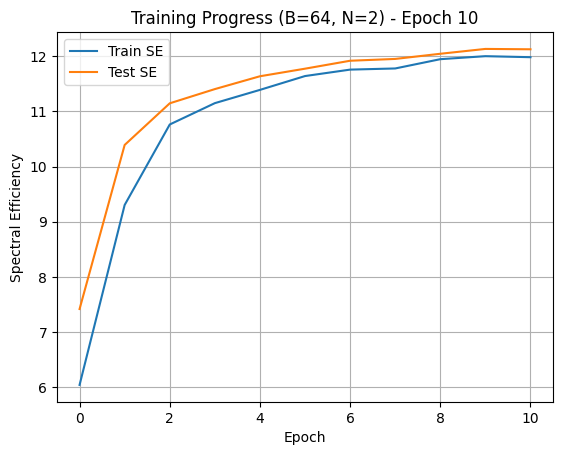

[TempCheck] GPU:78°C
Epoch: 11 | Time: 0:01:12.440672 | Train SE: 12.096 | Test SE: 12.277
New best model saved with Test SE: 12.2765
[TempCheck] GPU:82°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 12 | Time: 0:02:11.351223 | Train SE: 12.179 | Test SE: 12.359
New best model saved with Test SE: 12.3592
[TempCheck] GPU:78°C
Epoch: 13 | Time: 0:01:12.396507 | Train SE: 12.283 | Test SE: 12.391
New best model saved with Test SE: 12.3914
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 14 | Time: 0:02:12.338876 | Train SE: 12.197 | Test SE: 12.324
[TempCheck] GPU:79°C
Epoch: 15 | Time: 0:01:14.154790 | Train SE: 12.157 | Test SE: 12.152
[TempCheck] GPU:80°C
Epoch: 16 | Time: 0:01:13.992685 | Train SE: 12.156 | Test SE: 12.347
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 17 | Time: 0:02:14.275370 | Train SE: 12.215 | Test SE: 12.280
[TempCheck] GPU:78°C
Epoch: 18 | Time: 0:01:13.943850 | Train SE: 12.282 | Test SE: 12.051
[TempCheck] GPU:80°C
Epoch: 19 | Time: 0:01:13.428738 | 

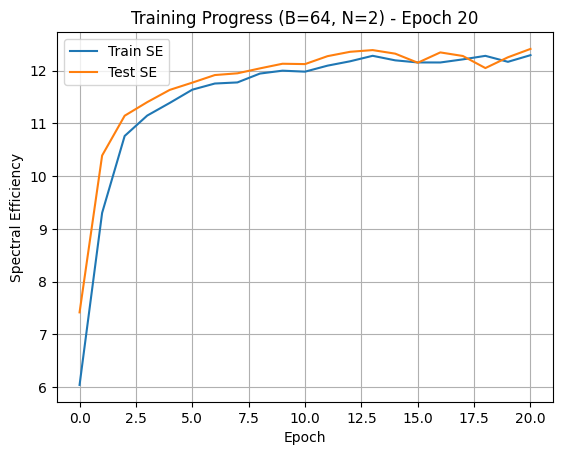

New best model saved with Test SE: 12.4137
[TempCheck] GPU:73°C
Epoch: 21 | Time: 0:01:13.820598 | Train SE: 12.268 | Test SE: 12.311
[TempCheck] GPU:80°C
Epoch: 22 | Time: 0:01:13.246550 | Train SE: 12.152 | Test SE: 12.296
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 23 | Time: 0:02:12.827577 | Train SE: 12.193 | Test SE: 12.303
[TempCheck] GPU:77°C
Epoch: 24 | Time: 0:01:13.020964 | Train SE: 12.075 | Test SE: 12.223
[TempCheck] GPU:80°C
Epoch: 25 | Time: 0:01:11.581999 | Train SE: 12.155 | Test SE: 12.298
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 26 | Time: 0:02:14.612612 | Train SE: 12.212 | Test SE: 12.318
[TempCheck] GPU:78°C
Epoch: 27 | Time: 0:01:13.369382 | Train SE: 12.127 | Test SE: 12.201
[TempCheck] GPU:80°C
Epoch: 28 | Time: 0:01:13.354130 | Train SE: 11.981 | Test SE: 12.079
[TempCheck] GPU:80°C
Epoch: 29 | Time: 0:01:13.322994 | Train SE: 11.929 | Test SE: 12.168
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 30 | Time: 0:02:13.0406

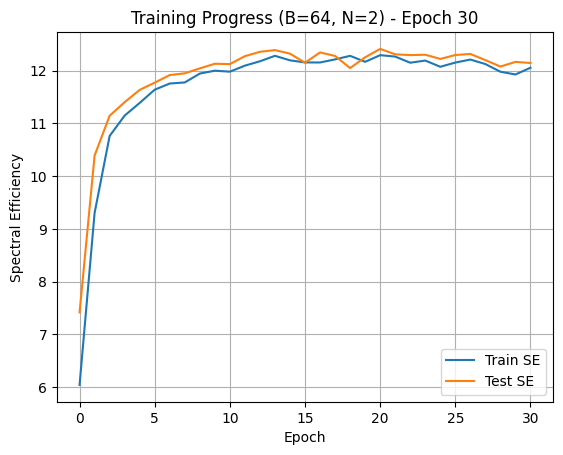

[TempCheck] GPU:73°C
Epoch: 31 | Time: 0:01:13.624689 | Train SE: 11.994 | Test SE: 12.195
[TempCheck] GPU:79°C
Epoch: 32 | Time: 0:01:13.373677 | Train SE: 12.083 | Test SE: 12.148
[TempCheck] GPU:80°C
Epoch: 33 | Time: 0:01:12.951627 | Train SE: 12.194 | Test SE: 12.399
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 34 | Time: 0:02:12.641849 | Train SE: 12.271 | Test SE: 12.414
New best model saved with Test SE: 12.4140
[TempCheck] GPU:78°C
Epoch: 35 | Time: 0:01:12.890714 | Train SE: 12.113 | Test SE: 12.233
[TempCheck] GPU:80°C
Epoch: 36 | Time: 0:01:12.096400 | Train SE: 12.120 | Test SE: 12.233
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 37 | Time: 0:02:12.875305 | Train SE: 12.136 | Test SE: 12.338
[TempCheck] GPU:78°C
Epoch: 38 | Time: 0:01:11.350381 | Train SE: 12.263 | Test SE: 12.393
[TempCheck] GPU:80°C
Epoch: 39 | Time: 0:01:11.602616 | Train SE: 12.289 | Test SE: 12.376
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 40 | Time: 0:02:11.1055

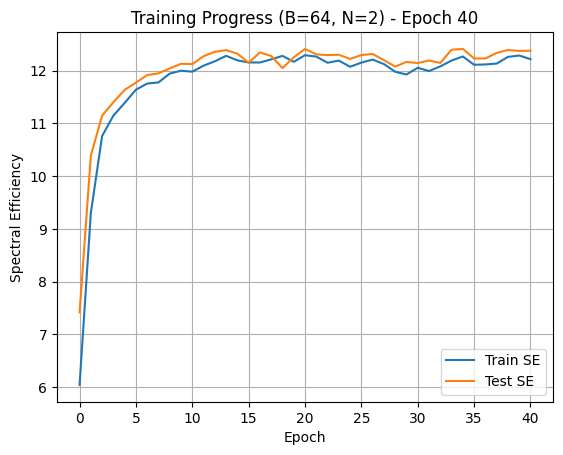

[TempCheck] GPU:78°C
Epoch: 41 | Time: 0:01:11.477998 | Train SE: 12.106 | Test SE: 12.279
[TempCheck] GPU:80°C
Epoch: 42 | Time: 0:01:11.632947 | Train SE: 12.169 | Test SE: 12.215
[TempCheck] GPU:80°C
Epoch: 43 | Time: 0:01:11.473013 | Train SE: 11.945 | Test SE: 12.103
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 44 | Time: 0:02:11.295731 | Train SE: 12.109 | Test SE: 12.332
[TempCheck] GPU:78°C
Epoch: 45 | Time: 0:01:11.395250 | Train SE: 12.202 | Test SE: 12.314
[TempCheck] GPU:80°C
Epoch: 46 | Time: 0:01:11.373293 | Train SE: 12.297 | Test SE: 12.461
New best model saved with Test SE: 12.4610
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 47 | Time: 0:02:12.117052 | Train SE: 12.394 | Test SE: 12.540
New best model saved with Test SE: 12.5400
[TempCheck] GPU:78°C
Epoch: 48 | Time: 0:01:11.336496 | Train SE: 12.462 | Test SE: 12.561
New best model saved with Test SE: 12.5610
[TempCheck] GPU:80°C
Epoch: 49 | Time: 0:01:11.270371 | Train SE: 12.339 | Test SE: 1

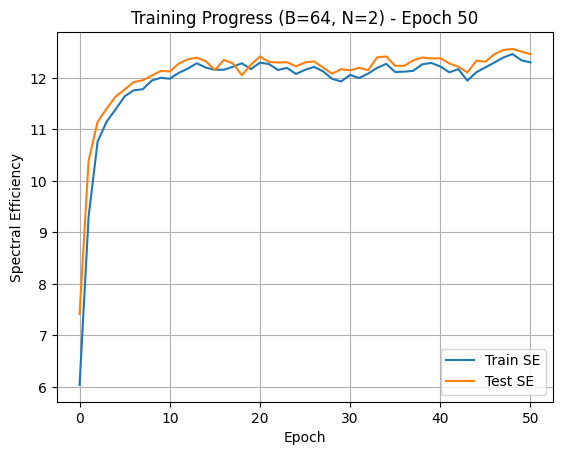

[TempCheck] GPU:78°C
Epoch: 51 | Time: 0:01:11.383824 | Train SE: 12.402 | Test SE: 12.435
[TempCheck] GPU:80°C
Epoch: 52 | Time: 0:01:11.432639 | Train SE: 12.359 | Test SE: 12.495
[TempCheck] GPU:80°C
Epoch: 53 | Time: 0:01:11.825542 | Train SE: 12.381 | Test SE: 12.405
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 54 | Time: 0:02:10.994874 | Train SE: 12.339 | Test SE: 12.470
[TempCheck] GPU:78°C
Epoch: 55 | Time: 0:01:11.410753 | Train SE: 12.432 | Test SE: 12.560
[TempCheck] GPU:80°C
Epoch: 56 | Time: 0:01:11.398443 | Train SE: 12.473 | Test SE: 12.597
New best model saved with Test SE: 12.5967
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 57 | Time: 0:02:11.809802 | Train SE: 12.408 | Test SE: 12.501
[TempCheck] GPU:77°C
Epoch: 58 | Time: 0:01:11.561487 | Train SE: 12.374 | Test SE: 12.505
[TempCheck] GPU:80°C
Epoch: 59 | Time: 0:01:14.811028 | Train SE: 12.395 | Test SE: 12.443
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 60 | Time: 0:02:13.3887

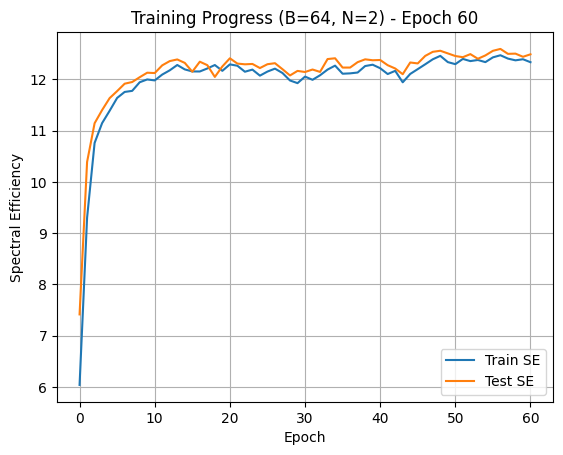

[TempCheck] GPU:79°C
Epoch: 61 | Time: 0:01:11.564149 | Train SE: 12.381 | Test SE: 12.274
[TempCheck] GPU:80°C
Epoch: 62 | Time: 0:01:11.367903 | Train SE: 12.098 | Test SE: 12.109
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 63 | Time: 0:02:11.115668 | Train SE: 12.140 | Test SE: 12.212
[TempCheck] GPU:78°C
Epoch: 64 | Time: 0:01:11.321183 | Train SE: 12.113 | Test SE: 12.185
[TempCheck] GPU:79°C
Epoch: 65 | Time: 0:01:11.556676 | Train SE: 12.064 | Test SE: 12.232
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 66 | Time: 0:02:11.357753 | Train SE: 12.004 | Test SE: 12.035
[TempCheck] GPU:78°C
Epoch: 67 | Time: 0:01:11.685914 | Train SE: 11.936 | Test SE: 12.264
[TempCheck] GPU:80°C
Epoch: 68 | Time: 0:01:13.688425 | Train SE: 12.020 | Test SE: 12.293
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 69 | Time: 0:02:12.952357 | Train SE: 12.162 | Test SE: 12.321
[TempCheck] GPU:77°C
Epoch: 70 | Time: 0:01:13.369615 | Train SE: 12.164 | Test SE: 12.318


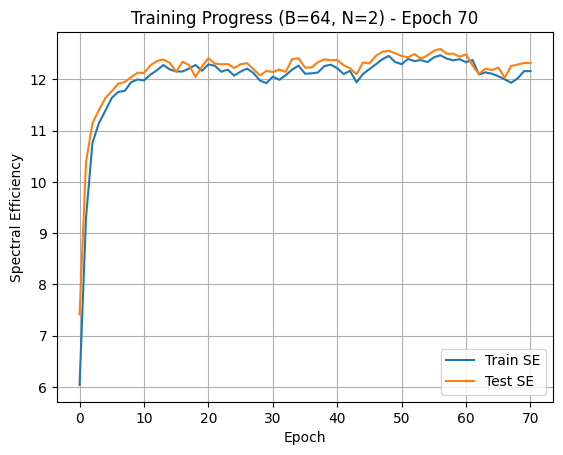

[TempCheck] GPU:76°C
Epoch: 71 | Time: 0:01:13.783221 | Train SE: 12.065 | Test SE: 12.090
[TempCheck] GPU:80°C
Epoch: 72 | Time: 0:01:13.329978 | Train SE: 11.938 | Test SE: 12.194
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 73 | Time: 0:02:13.068395 | Train SE: 12.012 | Test SE: 12.079
[TempCheck] GPU:77°C
Epoch: 74 | Time: 0:01:13.054026 | Train SE: 12.005 | Test SE: 12.201
[TempCheck] GPU:80°C
Epoch: 75 | Time: 0:01:13.116900 | Train SE: 12.119 | Test SE: 12.312
[TempCheck] GPU:80°C
Epoch: 76 | Time: 0:01:13.405357 | Train SE: 12.262 | Test SE: 12.250
[TempCheck] GPU:80°C
Epoch: 77 | Time: 0:01:14.654989 | Train SE: 12.215 | Test SE: 12.400
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 78 | Time: 0:02:13.150067 | Train SE: 12.191 | Test SE: 12.342
[TempCheck] GPU:77°C
Epoch: 79 | Time: 0:01:13.322275 | Train SE: 12.210 | Test SE: 12.375
[TempCheck] GPU:80°C
Epoch: 80 | Time: 0:01:13.346305 | Train SE: 12.209 | Test SE: 12.304


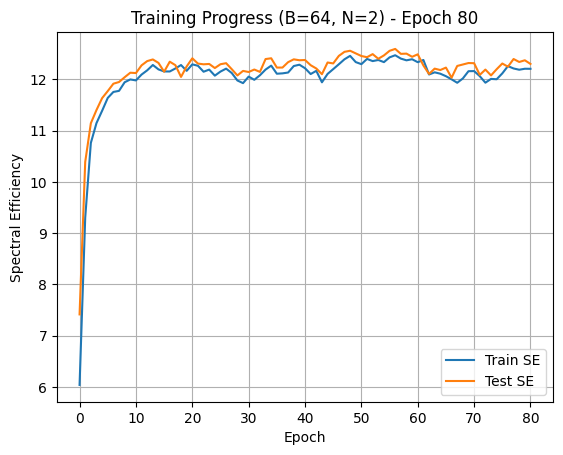

[TempCheck] GPU:80°C
Epoch: 81 | Time: 0:01:13.672388 | Train SE: 12.182 | Test SE: 12.198
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 82 | Time: 0:02:12.862850 | Train SE: 12.079 | Test SE: 12.273
[TempCheck] GPU:77°C
Epoch: 83 | Time: 0:01:12.797202 | Train SE: 12.097 | Test SE: 12.233
[TempCheck] GPU:80°C
Epoch: 84 | Time: 0:01:11.507252 | Train SE: 12.069 | Test SE: 12.200
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 85 | Time: 0:02:11.127735 | Train SE: 12.059 | Test SE: 12.223
[TempCheck] GPU:78°C
Epoch: 86 | Time: 0:01:11.457716 | Train SE: 12.082 | Test SE: 12.262
[TempCheck] GPU:80°C
Epoch: 87 | Time: 0:01:11.903403 | Train SE: 12.108 | Test SE: 12.322
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 88 | Time: 0:02:11.087896 | Train SE: 12.082 | Test SE: 12.284
[TempCheck] GPU:78°C
Epoch: 89 | Time: 0:01:11.112113 | Train SE: 12.096 | Test SE: 12.325
[TempCheck] GPU:80°C
Epoch: 90 | Time: 0:01:11.686470 | Train SE: 12.177 | Test SE: 12.388


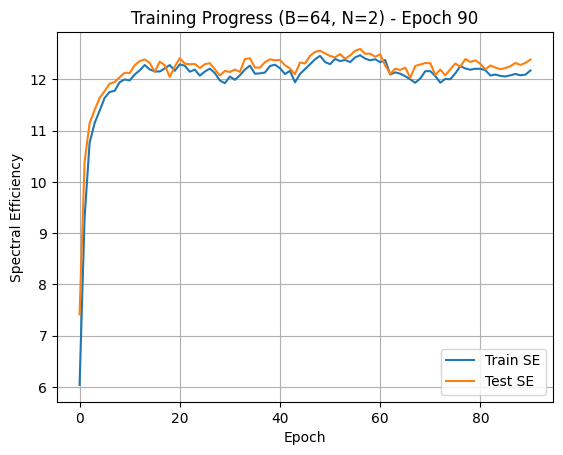

[TempCheck] GPU:80°C
Epoch: 91 | Time: 0:01:11.735413 | Train SE: 12.168 | Test SE: 12.314
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 92 | Time: 0:02:11.263250 | Train SE: 12.132 | Test SE: 12.276
[TempCheck] GPU:78°C
Epoch: 93 | Time: 0:01:11.697335 | Train SE: 12.144 | Test SE: 12.198
[TempCheck] GPU:80°C
Epoch: 94 | Time: 0:01:11.516800 | Train SE: 12.006 | Test SE: 12.226
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 95 | Time: 0:02:11.735412 | Train SE: 12.001 | Test SE: 12.159
[TempCheck] GPU:78°C
Epoch: 96 | Time: 0:01:13.343837 | Train SE: 11.956 | Test SE: 12.139
[TempCheck] GPU:80°C
Epoch: 97 | Time: 0:01:13.712811 | Train SE: 12.017 | Test SE: 12.048
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 98 | Time: 0:02:13.188761 | Train SE: 11.990 | Test SE: 12.330
[TempCheck] GPU:77°C
Epoch: 99 | Time: 0:01:12.944913 | Train SE: 12.050 | Test SE: 12.245
[TempCheck] GPU:80°C
Epoch: 100 | Time: 0:01:13.349604 | Train SE: 12.230 | Test SE: 12.430


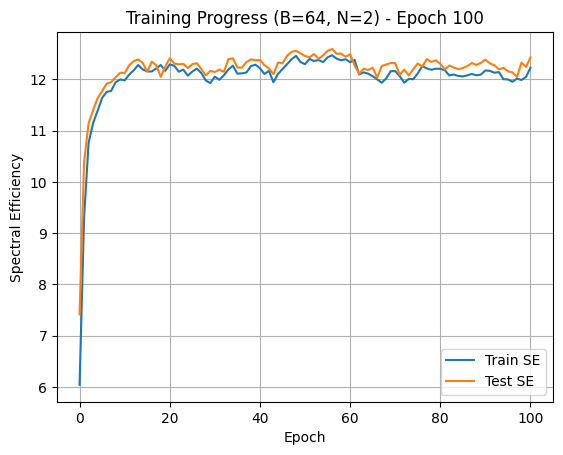

[TempCheck] GPU:80°C
Epoch: 101 | Time: 0:01:13.769936 | Train SE: 12.215 | Test SE: 12.354
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 102 | Time: 0:02:12.993430 | Train SE: 12.188 | Test SE: 12.321
[TempCheck] GPU:77°C
Epoch: 103 | Time: 0:01:13.317811 | Train SE: 12.143 | Test SE: 12.265
[TempCheck] GPU:79°C
Epoch: 104 | Time: 0:01:13.369316 | Train SE: 12.165 | Test SE: 12.365
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 105 | Time: 0:02:12.991707 | Train SE: 12.254 | Test SE: 12.405
[TempCheck] GPU:78°C
Epoch: 106 | Time: 0:01:13.832984 | Train SE: 12.297 | Test SE: 12.293
[TempCheck] GPU:80°C
Epoch: 107 | Time: 0:01:14.943066 | Train SE: 12.239 | Test SE: 12.419
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 108 | Time: 0:02:14.092489 | Train SE: 12.243 | Test SE: 12.368
[TempCheck] GPU:79°C
Epoch: 109 | Time: 0:01:13.511255 | Train SE: 12.241 | Test SE: 12.350
[TempCheck] GPU:80°C
Epoch: 110 | Time: 0:01:12.144702 | Train SE: 12.207 | Test SE: 

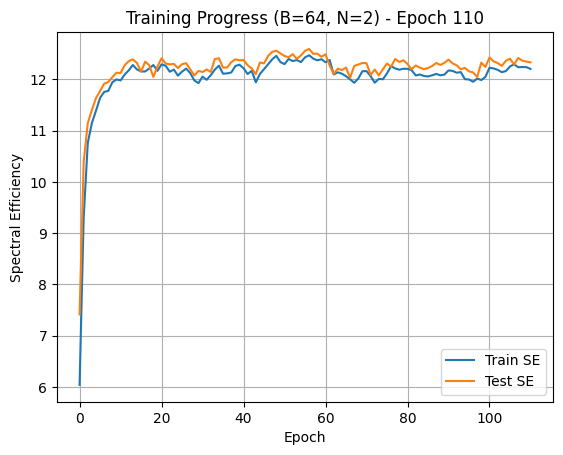

[TempCheck] GPU:79°C
Epoch: 111 | Time: 0:01:12.106117 | Train SE: 12.168 | Test SE: 12.328
[TempCheck] GPU:82°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 112 | Time: 0:02:11.432631 | Train SE: 12.199 | Test SE: 12.344
[TempCheck] GPU:80°C
Epoch: 113 | Time: 0:01:11.407040 | Train SE: 12.260 | Test SE: 12.462
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 114 | Time: 0:02:13.652941 | Train SE: 12.185 | Test SE: 12.291
[TempCheck] GPU:79°C
Epoch: 115 | Time: 0:01:13.526567 | Train SE: 12.131 | Test SE: 12.168
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 116 | Time: 0:02:13.197655 | Train SE: 12.025 | Test SE: 12.251
[TempCheck] GPU:78°C
Epoch: 117 | Time: 0:01:13.138349 | Train SE: 12.158 | Test SE: 12.350
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 118 | Time: 0:02:12.151621 | Train SE: 12.231 | Test SE: 12.408
[TempCheck] GPU:78°C
Epoch: 119 | Time: 0:01:11.262662 | Train SE: 12.285 | Test SE: 12.379
[TempCheck] GPU:80°C
Epoch: 120 | Time: 0:01:12.870138 |

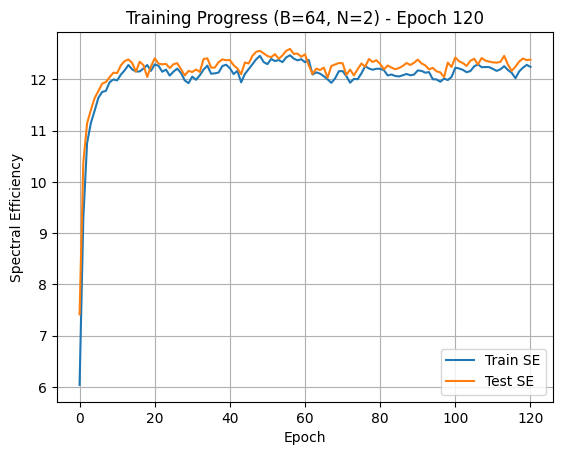

[TempCheck] GPU:79°C
Epoch: 121 | Time: 0:01:14.204057 | Train SE: 12.266 | Test SE: 12.381
[TempCheck] GPU:82°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 122 | Time: 0:02:12.883995 | Train SE: 12.259 | Test SE: 12.422
[TempCheck] GPU:77°C
Epoch: 123 | Time: 0:01:13.260855 | Train SE: 12.305 | Test SE: 12.436
[TempCheck] GPU:80°C
Epoch: 124 | Time: 0:01:13.750264 | Train SE: 12.326 | Test SE: 12.477
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 125 | Time: 0:02:13.031894 | Train SE: 12.375 | Test SE: 12.519
[TempCheck] GPU:78°C
Epoch: 126 | Time: 0:01:13.804141 | Train SE: 12.351 | Test SE: 12.469
[TempCheck] GPU:80°C
Epoch: 127 | Time: 0:01:14.264755 | Train SE: 12.308 | Test SE: 12.423
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 128 | Time: 0:02:12.095110 | Train SE: 12.286 | Test SE: 12.439
[TempCheck] GPU:78°C
Epoch: 129 | Time: 0:01:12.164883 | Train SE: 12.340 | Test SE: 12.425
[TempCheck] GPU:80°C
Epoch: 130 | Time: 0:01:12.884028 | Train SE: 12.249 | Test SE: 

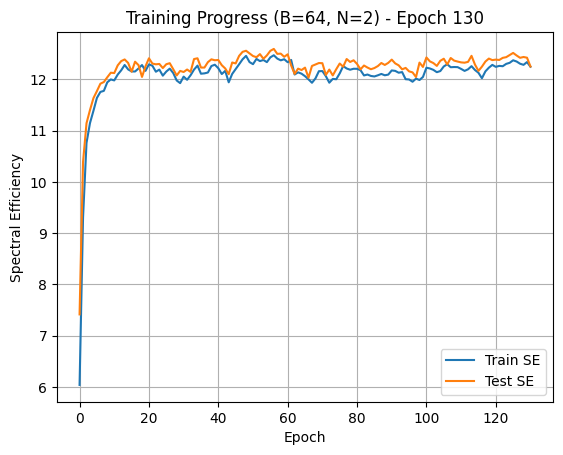

[TempCheck] GPU:82°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 131 | Time: 0:02:13.428622 | Train SE: 12.081 | Test SE: 12.224
[TempCheck] GPU:78°C
Epoch: 132 | Time: 0:01:12.665814 | Train SE: 12.093 | Test SE: 12.306
[TempCheck] GPU:80°C
Epoch: 133 | Time: 0:01:13.249681 | Train SE: 12.130 | Test SE: 12.366
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 134 | Time: 0:02:11.240298 | Train SE: 12.146 | Test SE: 12.346
[TempCheck] GPU:78°C
Epoch: 135 | Time: 0:01:11.979203 | Train SE: 12.180 | Test SE: 12.374
[TempCheck] GPU:80°C
Epoch: 136 | Time: 0:01:13.798802 | Train SE: 12.232 | Test SE: 12.450
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 137 | Time: 0:02:13.388646 | Train SE: 12.228 | Test SE: 12.393
[TempCheck] GPU:77°C
Epoch: 138 | Time: 0:01:13.141602 | Train SE: 12.193 | Test SE: 12.438
[TempCheck] GPU:79°C
Epoch: 139 | Time: 0:01:13.537815 | Train SE: 12.265 | Test SE: 12.454
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 140 | Time: 0:02:13.047471 |

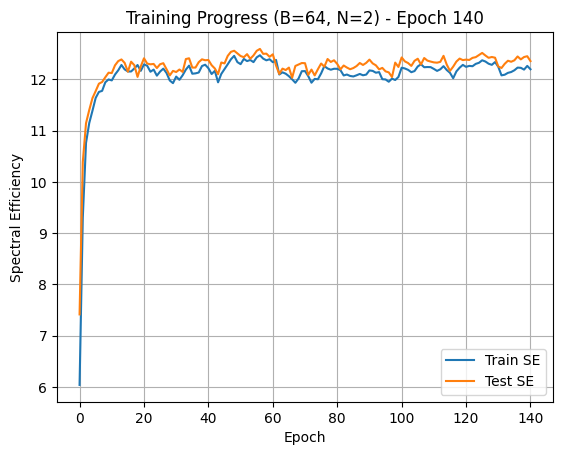

[TempCheck] GPU:77°C
Epoch: 141 | Time: 0:01:14.182924 | Train SE: 12.224 | Test SE: 12.449
[TempCheck] GPU:80°C
Epoch: 142 | Time: 0:01:14.235628 | Train SE: 12.290 | Test SE: 12.454
[TempCheck] GPU:80°C
Epoch: 143 | Time: 0:01:14.326062 | Train SE: 12.317 | Test SE: 12.484
[TempCheck] GPU:82°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 144 | Time: 0:02:12.954665 | Train SE: 12.332 | Test SE: 12.509
[TempCheck] GPU:78°C
Epoch: 145 | Time: 0:01:13.310495 | Train SE: 12.345 | Test SE: 12.493
[TempCheck] GPU:80°C
Epoch: 146 | Time: 0:01:13.571540 | Train SE: 12.370 | Test SE: 12.534
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 147 | Time: 0:02:14.038931 | Train SE: 12.357 | Test SE: 12.507
[TempCheck] GPU:78°C
Epoch: 148 | Time: 0:01:13.465581 | Train SE: 12.335 | Test SE: 12.473
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 149 | Time: 0:02:13.646783 | Train SE: 12.236 | Test SE: 12.485
[TempCheck] GPU:79°C
Epoch: 150 | Time: 0:01:13.577216 | Train SE: 12.389 | Test SE: 

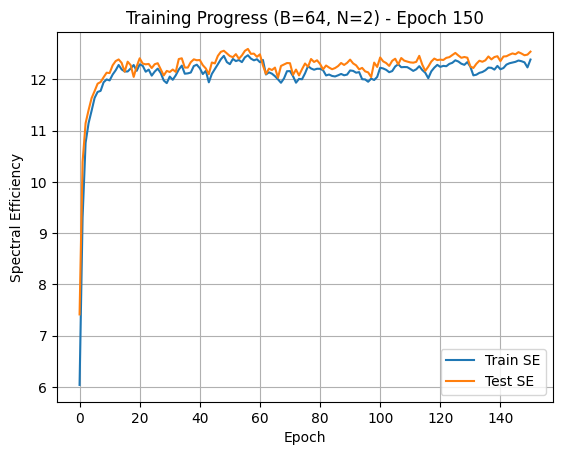

[TempCheck] GPU:80°C
Epoch: 151 | Time: 0:01:15.259855 | Train SE: 12.441 | Test SE: 12.491
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 152 | Time: 0:02:13.749818 | Train SE: 12.420 | Test SE: 12.578
[TempCheck] GPU:78°C
Epoch: 153 | Time: 0:01:13.370701 | Train SE: 12.421 | Test SE: 12.561
[TempCheck] GPU:80°C
Epoch: 154 | Time: 0:01:13.472314 | Train SE: 12.442 | Test SE: 12.596
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 155 | Time: 0:02:14.117193 | Train SE: 12.435 | Test SE: 12.602
New best model saved with Test SE: 12.6021
[TempCheck] GPU:78°C
Epoch: 156 | Time: 0:01:13.664801 | Train SE: 12.476 | Test SE: 12.571
[TempCheck] GPU:80°C
Epoch: 157 | Time: 0:01:13.770356 | Train SE: 12.439 | Test SE: 12.580
[TempCheck] GPU:80°C
Epoch: 158 | Time: 0:01:13.896301 | Train SE: 12.444 | Test SE: 12.572
[TempCheck] GPU:82°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 159 | Time: 0:02:13.396794 | Train SE: 12.473 | Test SE: 12.571
[TempCheck] GPU:77°C
Epoch: 160 | Time: 0:

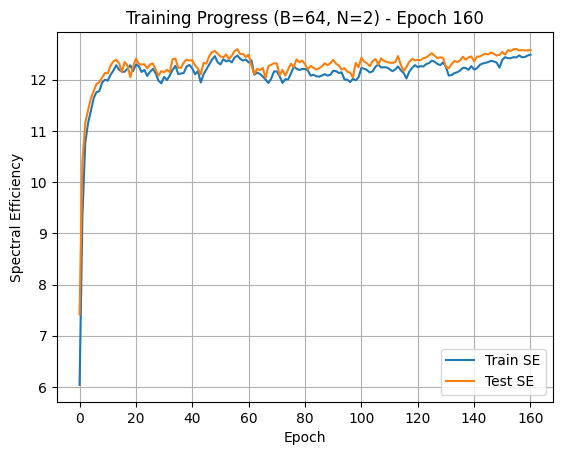

[TempCheck] GPU:80°C
Epoch: 161 | Time: 0:01:13.929147 | Train SE: 12.474 | Test SE: 12.602
New best model saved with Test SE: 12.6024
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 162 | Time: 0:02:14.673022 | Train SE: 12.479 | Test SE: 12.548
[TempCheck] GPU:79°C
Epoch: 163 | Time: 0:01:14.485636 | Train SE: 12.423 | Test SE: 12.553
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 164 | Time: 0:02:13.188667 | Train SE: 12.438 | Test SE: 12.532
[TempCheck] GPU:77°C
Epoch: 165 | Time: 0:01:14.245634 | Train SE: 12.443 | Test SE: 12.572
[TempCheck] GPU:79°C
Epoch: 166 | Time: 0:01:13.597564 | Train SE: 12.450 | Test SE: 12.590
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 167 | Time: 0:02:13.354633 | Train SE: 12.431 | Test SE: 12.494
[TempCheck] GPU:77°C
Epoch: 168 | Time: 0:01:13.474095 | Train SE: 12.381 | Test SE: 12.549
[TempCheck] GPU:80°C
Epoch: 169 | Time: 0:01:13.485024 | Train SE: 12.423 | Test SE: 12.524
[TempCheck] GPU:80°C
Epoch: 170 | Time: 0:

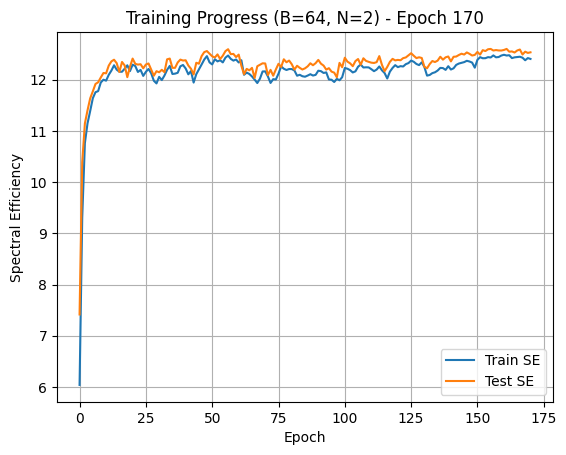

[TempCheck] GPU:79°C
Epoch: 171 | Time: 0:01:14.715095 | Train SE: 12.420 | Test SE: 12.566
[TempCheck] GPU:82°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 172 | Time: 0:02:13.639468 | Train SE: 12.414 | Test SE: 12.528
[TempCheck] GPU:78°C
Epoch: 173 | Time: 0:01:13.881791 | Train SE: 12.401 | Test SE: 12.548
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 174 | Time: 0:02:13.211138 | Train SE: 12.423 | Test SE: 12.539
[TempCheck] GPU:78°C
Epoch: 175 | Time: 0:01:14.935504 | Train SE: 12.424 | Test SE: 12.532
[TempCheck] GPU:80°C
Epoch: 176 | Time: 0:01:14.853707 | Train SE: 12.420 | Test SE: 12.546
[TempCheck] GPU:81°C
[TempCheck] GPU 过热，暂停 60 秒冷却
Epoch: 177 | Time: 0:02:14.122717 | Train SE: 12.413 | Test SE: 12.540
[TempCheck] GPU:79°C
Epoch: 178 | Time: 0:01:13.543025 | Train SE: 12.381 | Test SE: 12.522
[TempCheck] GPU:79°C
Epoch: 179 | Time: 0:01:13.515156 | Train SE: 12.403 | Test SE: 12.541


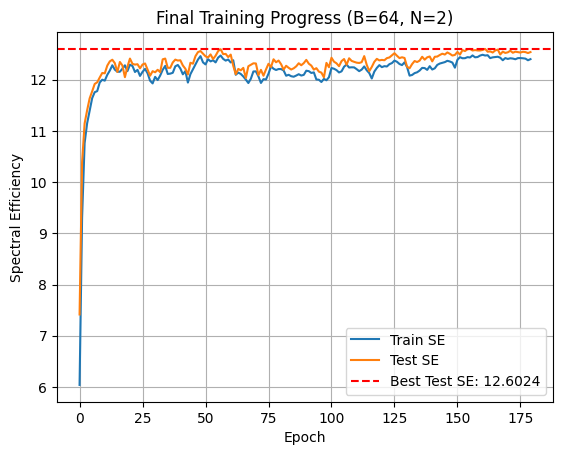

The best SE is: 12.602
[ 7.41568953 10.39108915 11.14621561 11.40385711 11.63663292 11.77404983
 11.91799662 11.95086303 12.04452467 12.13241708 12.12576089 12.27651212
 12.35918474 12.39136195 12.3238101  12.15172479 12.34744041 12.27969856
 12.05056643 12.25503109 12.41367617 12.31063728 12.29648585 12.30341213
 12.22347784 12.29811714 12.3181504  12.2009141  12.07898421 12.16762073
 12.14622221 12.19457326 12.1481792  12.39896328 12.41402528 12.23288753
 12.23305953 12.33835843 12.39346738 12.3757009  12.38046644 12.27893431
 12.21472654 12.10346842 12.33187912 12.31361041 12.46104372 12.53996339
 12.56096153 12.50954409 12.45811949 12.43517461 12.49517443 12.40462601
 12.46994965 12.55967915 12.59671924 12.50054085 12.50484815 12.4430738
 12.49125941 12.27370563 12.10872447 12.21205382 12.18466494 12.23216772
 12.03487484 12.26431289 12.29285336 12.32123079 12.3181618  12.08999925
 12.19354875 12.07945521 12.20075531 12.31205812 12.24962385 12.39985337
 12.34207985 12.37500184 12.3

In [8]:
SEED = 1754208571
set_seed(SEED)
B = 64
train(Nc, N, Nt, B, Nr, L, SNR_dB, K, EPOCH, BATCH_SIZE)

In [9]:
# SEED = 1754215421
# set_seed(SEED)
# B = 32
# train(Nc, N, Nt, B, Nr, L, SNR_dB, K, EPOCH, BATCH_SIZE)

In [10]:
# B = 48
# train(Nc, N, Nt, B, Nr, L, SNR_dB, K, EPOCH, BATCH_SIZE)